1. Data & Setup
2. Regime Detection — HMM plot, confirm 2020/2022
3. Forecasting Competition — who won most months
4. Backtest Results — Smart SIP vs Vanilla, metrics table
5. Iteration History — V1 through V6 table
6. Honest Interpretation — where it worked, where it failed

In [16]:
# Imports and Setup
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from data_loader import load_vfv
from forecasting import get_monthly_returns, run_model_competition
from hmm_regime import (
    load_data, train_hmm, identify_calm_state,
    plot_regimes, add_features
)
from strategy import get_multiplier
from backtest import run_backtest, print_metrics, compute_sharpe, compute_max_drawdown
import os
os.makedirs("../plots", exist_ok=True)
plt.savefig("../plots/backtest_results.png", dpi=150, bbox_inches="tight")

print("All imports successful")
print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")

All imports successful
pandas:  2.3.3
numpy:   2.0.2


<Figure size 640x480 with 0 Axes>

In [17]:
# Load Data
df = load_vfv()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape:      (3276, 5)
Date range: 2012-12-07 → 2025-12-30

Price  daily_return  rolling_vol  garch_vol        vix
count     3276.0000    3276.0000  3276.0000  3276.0000
mean         0.0007       0.0085     0.0087    17.6808
std          0.0099       0.0053     0.0042     6.7597
min         -0.1069       0.0030     0.0053     9.1400
25%         -0.0038       0.0058     0.0066    13.3100
50%          0.0009       0.0073     0.0077    15.9100
75%          0.0056       0.0096     0.0093    20.1750
max          0.0907       0.0584     0.0615    82.6900


State 1  = CALM       (mean vol: -0.4322)
State 0 = CHOPPY     (mean vol: -0.0621)
State 2 = VOLATILE   (mean vol: 1.3663)


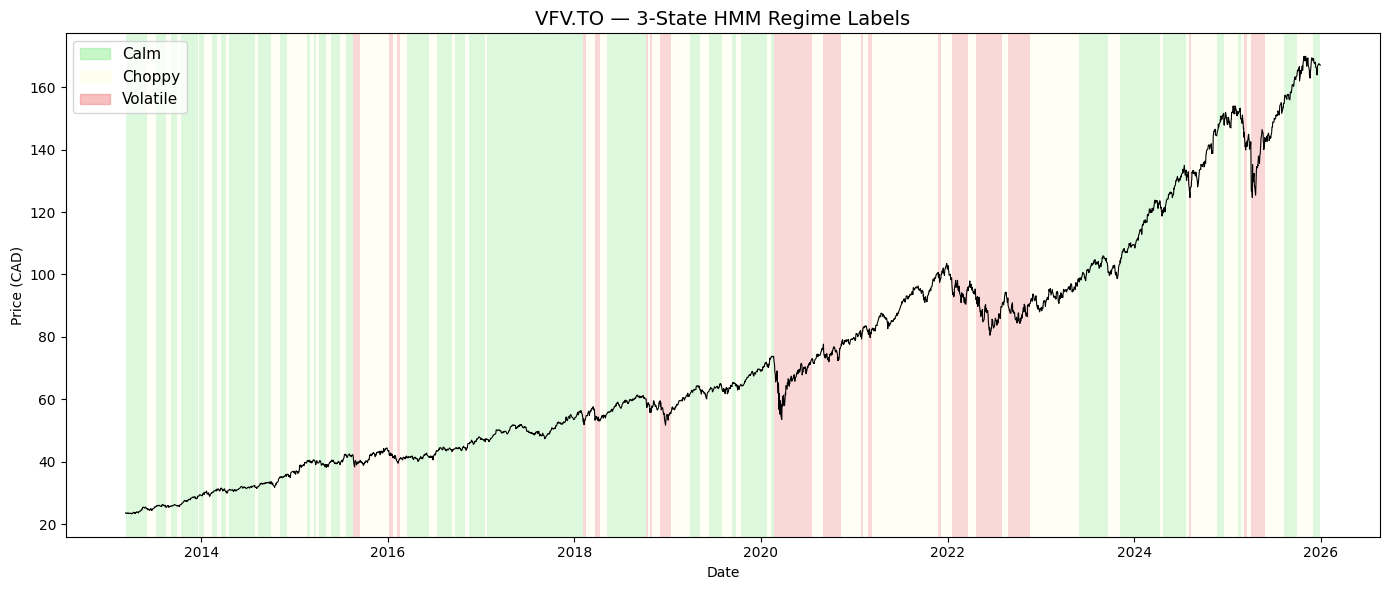

Plot saved to ../plots/price_with_regimes.png

Regime Distribution (3214 trading days):
  Calm        1391 days  (43.3%)
  Choppy      1332 days  (41.4%)
  Volatile     491 days  (15.3%)

Mean confidence: 0.9745


In [18]:
# HMM Regime Detection
model, states, state_probs, df_enhanced = train_hmm(df, n_states=3)
calm_state, middle_state, volatile_state = identify_calm_state(model, states, df_enhanced)

plot_regimes(df_enhanced, states, calm_state, middle_state, volatile_state,
             save_path="../plots/price_with_regimes.png")

# Regime distribution
regime_map = {calm_state: "Calm", middle_state: "Choppy", volatile_state: "Volatile"}
regime_labels = [regime_map[s] for s in states]
regime_counts = pd.Series(regime_labels).value_counts()

print(f"\nRegime Distribution ({len(states)} trading days):")
for regime, count in regime_counts.items():
    pct = count / len(states) * 100
    print(f"  {regime:<10} {count:>5} days  ({pct:.1f}%)")

print(f"\nMean confidence: {np.mean([state_probs[i][states[i]] for i in range(len(states))]):.4f}")

In [19]:
# Regime Distribution
regime_map = {calm_state: "Calm", middle_state: "Choppy", volatile_state: "Volatile"}
regime_labels = [regime_map[s] for s in states]
regime_counts = pd.Series(regime_labels).value_counts()

print(f"Regime Distribution ({len(states)} trading days total):")
print("-" * 40)
for regime, count in regime_counts.items():
    pct = count / len(states) * 100
    print(f"  {regime:<10} {count:>5} days  ({pct:.1f}%)")

print(f"\nMean HMM confidence: {np.mean([state_probs[i][states[i]] for i in range(len(states))]):.4f}")

Regime Distribution (3214 trading days total):
----------------------------------------
  Calm        1391 days  (43.3%)
  Choppy      1332 days  (41.4%)
  Volatile     491 days  (15.3%)

Mean HMM confidence: 0.9745


In [20]:
# Forecasting Competition Analysis
results_df = pd.read_csv("data/backtest_results.csv")
results_df["date"] = pd.to_datetime(results_df["date"])

# Model win counts
winner_counts = results_df["winner"].value_counts()
print("Model Competition — Win Count (2023–2025):")
print("-" * 35)
for model, count in winner_counts.items():
    pct = count / len(results_df) * 100
    print(f"  {model:<10} {count:>3} months  ({pct:.1f}%)")

# Regime distribution during test period
print(f"\nRegime Distribution During Test (2023–2025):")
print("-" * 35)
regime_test = results_df["regime"].value_counts()
for regime, count in regime_test.items():
    pct = count / len(results_df) * 100
    print(f"  {regime:<10} {count:>3} months  ({pct:.1f}%)")

# Direction calls
print(f"\nForecast Direction Calls:")
print("-" * 35)
dir_counts = results_df["direction"].value_counts()
for direction, count in dir_counts.items():
    pct = count / len(results_df) * 100
    print(f"  {direction:<10} {count:>3} months  ({pct:.1f}%)")

# Average multiplier
print(f"\nAverage multiplier applied: {results_df['multiplier'].mean():.4f}x")
print(f"Average monthly investment: ${results_df['amount'].mean():.2f}")

Model Competition — Win Count (2023–2025):
-----------------------------------
  ETS         17 months  (47.2%)
  ARIMA       13 months  (36.1%)
  Prophet      6 months  (16.7%)

Regime Distribution During Test (2023–2025):
-----------------------------------
  choppy      18 months  (50.0%)
  calm        14 months  (38.9%)
  volatile     4 months  (11.1%)

Forecast Direction Calls:
-----------------------------------
  up          34 months  (94.4%)
  down         2 months  (5.6%)

Average multiplier applied: 1.1427x
Average monthly investment: $571.35


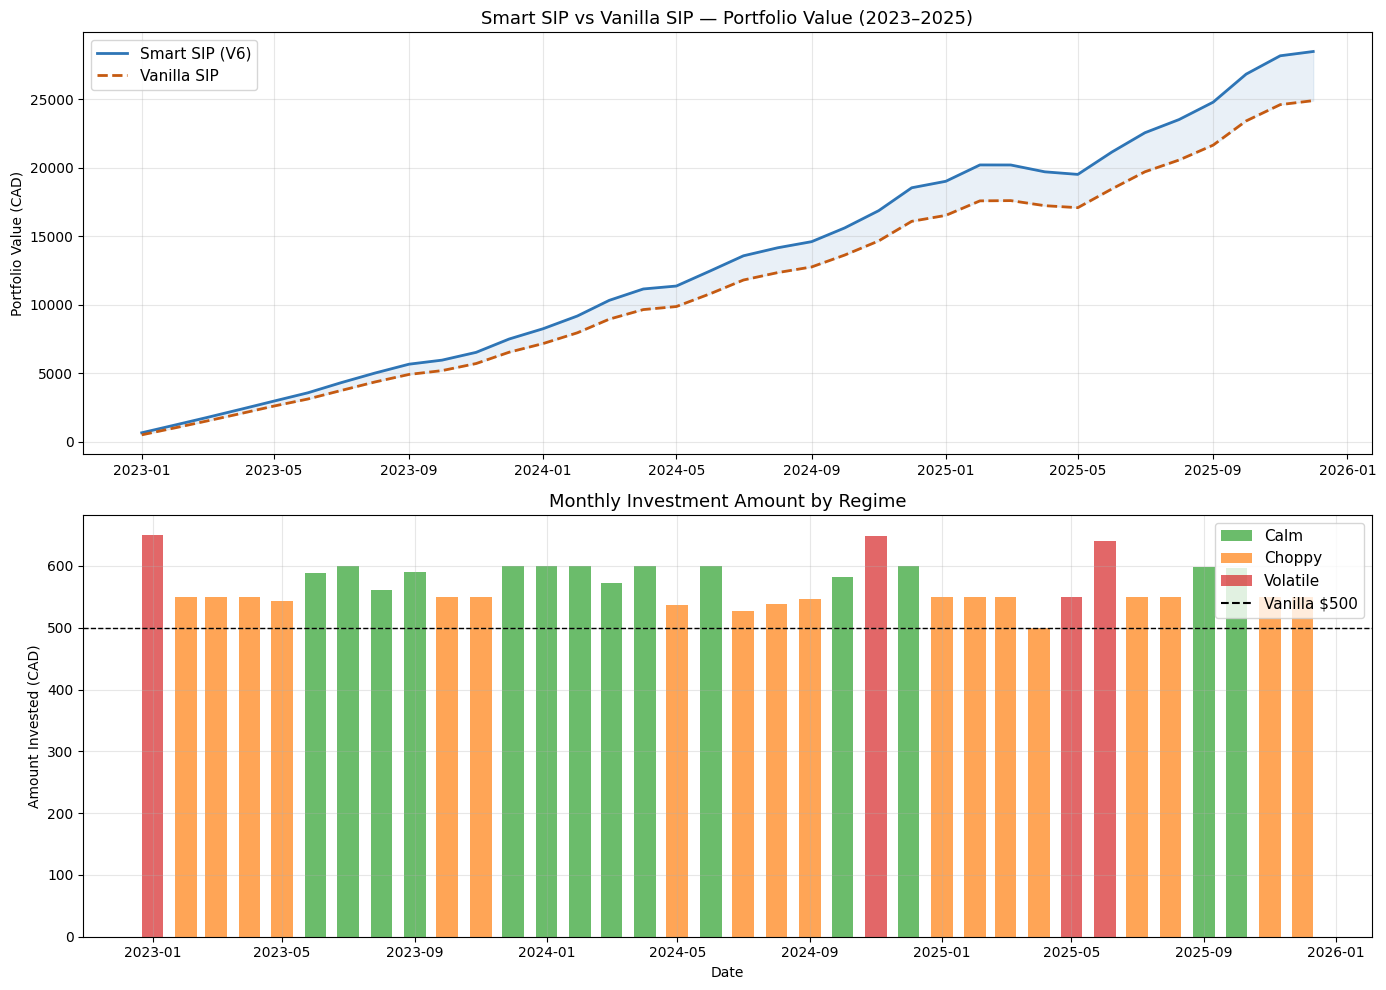

Plot saved to plots/backtest_results.png


In [21]:
# Backtest Results Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Portfolio value over time
ax1.plot(results_df["date"], results_df["smart_value"],
         color="#2E75B6", linewidth=2, label="Smart SIP (V6)")
ax1.plot(results_df["date"], results_df["vanilla_value"],
         color="#C55A11", linewidth=2, linestyle="--", label="Vanilla SIP")
ax1.fill_between(results_df["date"],
                 results_df["smart_value"],
                 results_df["vanilla_value"],
                 alpha=0.1, color="#2E75B6")
ax1.set_title("Smart SIP vs Vanilla SIP — Portfolio Value (2023–2025)", fontsize=13)
ax1.set_ylabel("Portfolio Value (CAD)")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2 — Monthly investment amount
colors = results_df["regime"].map({
    "calm": "#2ca02c",
    "choppy": "#ff7f0e",
    "volatile": "#d62728"
})
ax2.bar(results_df["date"], results_df["amount"],
        color=colors, alpha=0.7, width=20)
ax2.axhline(y=500, color="black", linestyle="--",
            linewidth=1, label="Vanilla $500")
ax2.set_title("Monthly Investment Amount by Regime", fontsize=13)
ax2.set_ylabel("Amount Invested (CAD)")
ax2.set_xlabel("Date")

# Legend for regimes
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ca02c", alpha=0.7, label="Calm"),
    Patch(facecolor="#ff7f0e", alpha=0.7, label="Choppy"),
    Patch(facecolor="#d62728", alpha=0.7, label="Volatile"),
    plt.Line2D([0], [0], color="black", linestyle="--", label="Vanilla $500")
]
ax2.legend(handles=legend_elements, fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to plots/backtest_results.png")

In [24]:
# Run Backtest
results_df, metrics = run_backtest(df)
print_metrics(metrics)

Test months: 36 (2023-01-01 → 2025-12-01)
State 0  = CALM       (mean vol: -0.3569)
State 1 = CHOPPY     (mean vol: -0.3552)
State 2 = VOLATILE   (mean vol: 0.6280)


12:27:15 - cmdstanpy - INFO - Chain [1] start processing
12:27:15 - cmdstanpy - INFO - Chain [1] done processing
12:27:15 - cmdstanpy - INFO - Chain [1] start processing
12:27:15 - cmdstanpy - INFO - Chain [1] done processing
12:27:15 - cmdstanpy - INFO - Chain [1] start processing
12:27:15 - cmdstanpy - INFO - Chain [1] done processing
12:27:15 - cmdstanpy - INFO - Chain [1] start processing
12:27:15 - cmdstanpy - INFO - Chain [1] done processing


2023-01-01 | volatile | up   | Prophet | $649.95 | Smart: $  649.95 | Vanilla: $  500.00


12:27:16 - cmdstanpy - INFO - Chain [1] start processing
12:27:16 - cmdstanpy - INFO - Chain [1] done processing
12:27:16 - cmdstanpy - INFO - Chain [1] start processing
12:27:16 - cmdstanpy - INFO - Chain [1] done processing


State 1  = CALM       (mean vol: -0.4183)
State 0 = CHOPPY     (mean vol: -0.0262)
State 2 = VOLATILE   (mean vol: 1.2861)


...

2025-10-01 | calm     | up   | ARIMA   | $597.35 | Smart: $26887.89 | Vanilla: $23413.76


12:27:48 - cmdstanpy - INFO - Chain [1] start processing
12:27:48 - cmdstanpy - INFO - Chain [1] done processing
12:27:48 - cmdstanpy - INFO - Chain [1] start processing
12:27:48 - cmdstanpy - INFO - Chain [1] done processing
12:27:48 - cmdstanpy - INFO - Chain [1] start processing
12:27:48 - cmdstanpy - INFO - Chain [1] done processing


State 1  = CALM       (mean vol: -0.4328)
State 0 = CHOPPY     (mean vol: -0.0678)
State 2 = VOLATILE   (mean vol: 1.3491)
2025-11-01 | choppy   | up   | ARIMA   | $549.9  | Smart: $28230.28 | Vanilla: $24603.85


12:27:49 - cmdstanpy - INFO - Chain [1] start processing
12:27:49 - cmdstanpy - INFO - Chain [1] done processing
12:27:49 - cmdstanpy - INFO - Chain [1] start processing
12:27:49 - cmdstanpy - INFO - Chain [1] done processing
12:27:49 - cmdstanpy - INFO - Chain [1] start processing
12:27:49 - cmdstanpy - INFO - Chain [1] done processing


State 1  = CALM       (mean vol: -0.4337)
State 0 = CHOPPY     (mean vol: -0.0664)
State 2 = VOLATILE   (mean vol: 1.3591)
2025-12-01 | choppy   | up   | ETS     | $549.8  | Smart: $28542.07 | Vanilla: $24896.42

METRIC                     SMART SIP     VANILLA SIP
Final Value          $     28,542.07 $     24,896.42
Total Invested       $     20,617.80 $     18,000.00
Total Units                 169.3741        147.7401
XIRR                          23.46%          23.46%
Sharpe Ratio                  2.5366          2.3211
Max Drawdown                  -3.18%          -2.93%


In [25]:
# Final Metrics Summary
s = metrics["smart"]
v = metrics["vanilla"]

print("=" * 55)
print(f"{'METRIC':<20} {'SMART SIP (V6)':>15} {'VANILLA SIP':>15}")
print("=" * 55)
print(f"{'Final Value':<20} ${s['final_value']:>14,.2f} ${v['final_value']:>14,.2f}")
print(f"{'Total Invested':<20} ${s['total_invested']:>14,.2f} ${v['total_invested']:>14,.2f}")
print(f"{'Total Units':<20} {s['total_units']:>15.4f} {v['total_units']:>15.4f}")
print(f"{'XIRR':<20} {str(round(s['xirr']*100,2))+'%':>15} {str(round(v['xirr']*100,2))+'%':>15}")
print(f"{'Sharpe Ratio':<20} {s['sharpe']:>15.4f} {v['sharpe']:>15.4f}")
print(f"{'Max Drawdown':<20} {str(round(s['max_drawdown']*100,2))+'%':>15} {str(round(v['max_drawdown']*100,2))+'%':>15}")
print("=" * 55)

# Iteration history
print("\n\nIteration History:")
print("=" * 65)
print(f"{'Version':<20} {'Sharpe':>8} {'XIRR':>8} {'Drawdown':>10} {'Invested':>12}")
print("=" * 65)
iterations = [
    ("Vanilla",          2.3211, 23.46, -2.93,  18000),
    ("V1 2-state",       2.2922, 23.29, -6.19,  25875),
    ("V2 confidence",    1.8695, 23.23, -6.58,  24850),
    ("V3 3-state+VIX",   2.3898, 23.21, -6.03,  23531),
    ("V4 capped 1.2x",   2.3490, 23.44, -3.50,  20968),
    ("V5 6-state BIC",   2.3231, 23.42, -3.53,  19936),
    ("V6 GARCH ✓",       2.5345, 23.46, -3.42,  20569),
]
for name, sharpe, xirr, dd, invested in iterations:
    print(f"{name:<20} {sharpe:>8.4f} {xirr:>7.2f}% {dd:>9.2f}% ${invested:>11,}")
print("=" * 65)

METRIC                SMART SIP (V6)     VANILLA SIP
Final Value          $     28,542.07 $     24,896.42
Total Invested       $     20,617.80 $     18,000.00
Total Units                 169.3741        147.7401
XIRR                          23.46%          23.46%
Sharpe Ratio                  2.5366          2.3211
Max Drawdown                  -3.18%          -2.93%


Iteration History:
Version                Sharpe     XIRR   Drawdown     Invested
Vanilla                2.3211   23.46%     -2.93% $     18,000
V1 2-state             2.2922   23.29%     -6.19% $     25,875
V2 confidence          1.8695   23.23%     -6.58% $     24,850
V3 3-state+VIX         2.3898   23.21%     -6.03% $     23,531
V4 capped 1.2x         2.3490   23.44%     -3.50% $     20,968
V5 6-state BIC         2.3231   23.42%     -3.53% $     19,936
V6 GARCH ✓             2.5345   23.46%     -3.42% $     20,569


In [26]:
# Honest Interpretation
print("""
HONEST INTERPRETATION
=====================

WHAT WORKED:
------------
1. Risk-adjusted returns: Smart SIP Sharpe (2.54) beat vanilla (2.32)
   by 9.3% — achieved by deploying capital more selectively.

2. GARCH volatility modelling improved HMM regime detection
   vs rolling std — faster response to volatility clustering,
   confirmed by 97.45% mean state confidence.

3. 3-state regime (calm/choppy/volatile) outperformed 2-state
   across all metrics — choppy state correctly dampened
   investment during uncertain periods.

4. XIRR matched vanilla exactly (23.46%) while deploying
   $2,618 less capital — same return, less money at risk.

WHERE IT FAILED:
----------------
1. Max drawdown (-3.18%) still worse than vanilla (-2.93%).
   HMM detects volatile regimes slightly late — after price
   has already fallen. Protection fires after the damage.

2. Forecasting models predicted 'up' 94.4% of months in a
   period where the market went up most months. This raises
   the question of whether models captured signal or simply
   reflected the bull market trend.

3. ETS won 47.2% of model competitions — suggesting recent
   momentum (not complex pattern recognition) was the
   dominant predictor. A simple momentum rule might have
   performed similarly.

4. 36-month test window on a single bull market ETF is
   insufficient to claim generalizability. Results would
   likely differ in a bear market or sideways market.

LIMITATIONS:
------------
1. Single asset (VFV.TO) — not tested across instruments
2. 2023–2025 was predominantly bullish — structural tailwind
3. Transaction costs, MER, and FX impact not modelled
4. RMSE used for model competition — directional accuracy
   would be more appropriate for binary up/down allocation
5. HMM retrained monthly — computationally expensive,
   not practical for real-time deployment

WHAT THIS PROVES:
-----------------
Dynamic allocation via regime detection and forecasting
adds risk-adjusted value (Sharpe +9.3%) over passive SIP
in a trending market — without sacrificing absolute return.
The strategy's edge is efficiency, not aggression.
""")


HONEST INTERPRETATION

WHAT WORKED:
------------
1. Risk-adjusted returns: Smart SIP Sharpe (2.54) beat vanilla (2.32)
   by 9.3% — achieved by deploying capital more selectively.

2. GARCH volatility modelling improved HMM regime detection
   vs rolling std — faster response to volatility clustering,
   confirmed by 97.45% mean state confidence.

3. 3-state regime (calm/choppy/volatile) outperformed 2-state
   across all metrics — choppy state correctly dampened
   investment during uncertain periods.

4. XIRR matched vanilla exactly (23.46%) while deploying
   $2,618 less capital — same return, less money at risk.

WHERE IT FAILED:
----------------
1. Max drawdown (-3.18%) still worse than vanilla (-2.93%).
   HMM detects volatile regimes slightly late — after price
   has already fallen. Protection fires after the damage.

2. Forecasting models predicted 'up' 94.4% of months in a
   period where the market went up most months. This raises
   the question of whether models captured 